# Exploring the Iris Dataset

## Project Overview

The Iris dataset is one of the most widely used datasets in statistics and machine learning. It contains measurements of iris flowers from three different species: Setosa, Versicolor, and Virginica.

The objective of this project is to perform Exploratory Data Analysis (EDA) to understand the characteristics of the dataset, compare the three flower species, and identify patterns through statistical summaries and data visualization.

The analysis includes:

- Loading and exploring the dataset
- Descriptive statistics
- Species distribution
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Species comparison
- Key insights and conclusions

# Table of Contents

1. Import Libraries
2. Load the Dataset
3. Explore the Dataset
4. Species Distribution
5. Univariate Analysis
6. Bivariate Analysis
7. Correlation Analysis
8. Species Comparison
9. Key Insights
10. Conclusion

## 1. Import Libraries

The first step is to import the Python libraries required for data manipulation and visualization.

- **Pandas** is used for handling tabular data.
- **Seaborn** provides built-in datasets and statistical visualizations.
- **Matplotlib** is used for creating plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

## 2. Load the Dataset

The Iris dataset is available directly through the Seaborn library. It contains measurements of iris flowers from three species:

- Setosa
- Versicolor
- Virginica

Each observation includes four numerical features and one categorical target variable representing the species.

In [2]:
iris = sns.load_dataset("iris")

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Dataset Shape:")
print(iris.shape)

Dataset Shape:
(150, 5)


In [5]:
print("\nData Types:")

iris.dtypes


Data Types:


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### Initial Observations

- The dataset contains measurements of iris flowers from three species.
- It consists of four numerical variables and one categorical variable.
- The dataset contains no missing values.
- The data is clean and ready for exploratory analysis.

## 3. Exploring the Dataset

Before visualizing the data, it is important to understand its overall structure and statistical properties.

In this section, we examine summary statistics, identify the range of each feature, and verify the quality of the dataset before proceeding with exploratory analysis.

In [8]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
iris.median(numeric_only=True)

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [10]:
feature_range = pd.DataFrame({
    "Minimum": iris.min(numeric_only=True),
    "Maximum": iris.max(numeric_only=True)
})

feature_range["Range"] = (
    feature_range["Maximum"]
    - feature_range["Minimum"]
)

feature_range

,Minimum,Maximum,Range
sepal_length,4.3,7.9,3.6
sepal_width,2.0,4.4,2.4
petal_length,1.0,6.9,5.9
petal_width,0.1,2.5,2.4


In [11]:
iris.std(numeric_only=True)

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

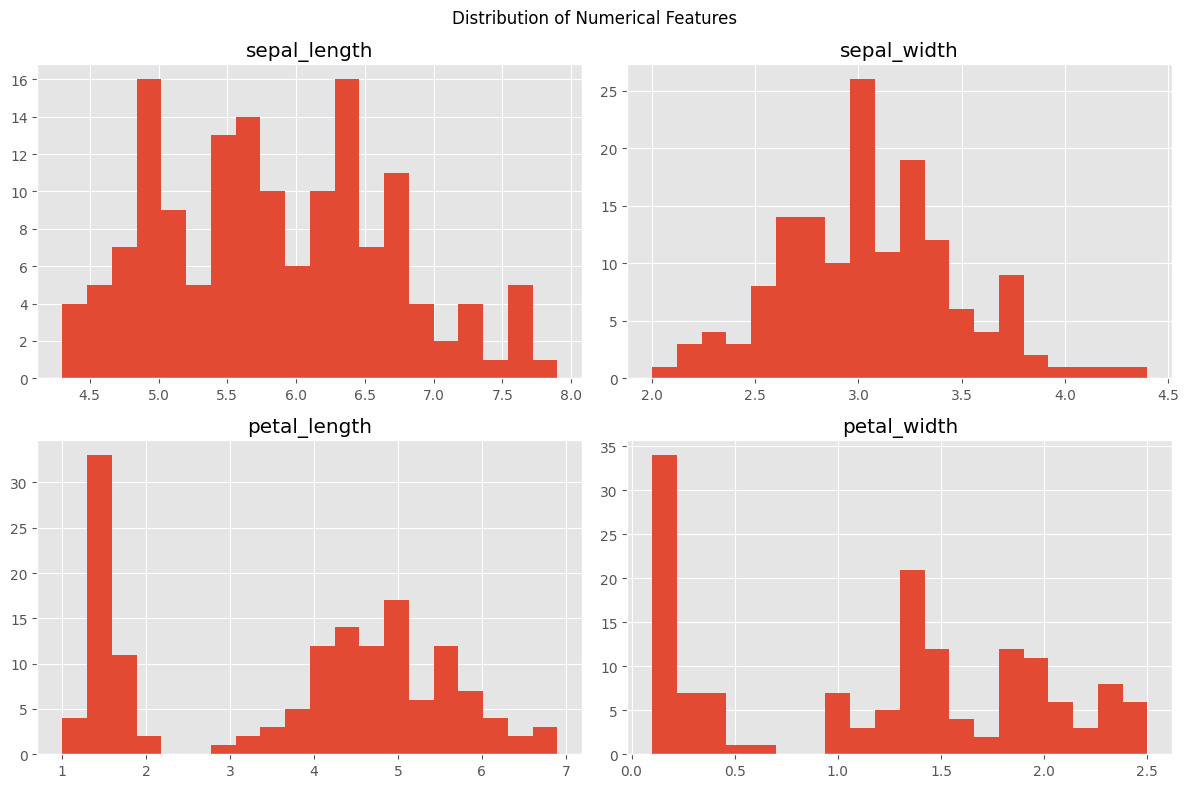

In [36]:
iris.hist(
    figsize=(12,8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()

plt.savefig(
    "images/distribution_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- The dataset contains 150 observations and four numerical features.
- No missing values are present, making the dataset suitable for analysis without preprocessing.
- The numerical variables differ in both scale and variability.
- Histograms suggest that some features are approximately symmetric, while others exhibit multiple peaks corresponding to different flower species.

## 4. Species Distribution

The target variable in the Iris dataset is the flower species.

Before analyzing the numerical features, it is useful to verify whether the dataset is balanced by examining the number of observations for each species.

In [13]:
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

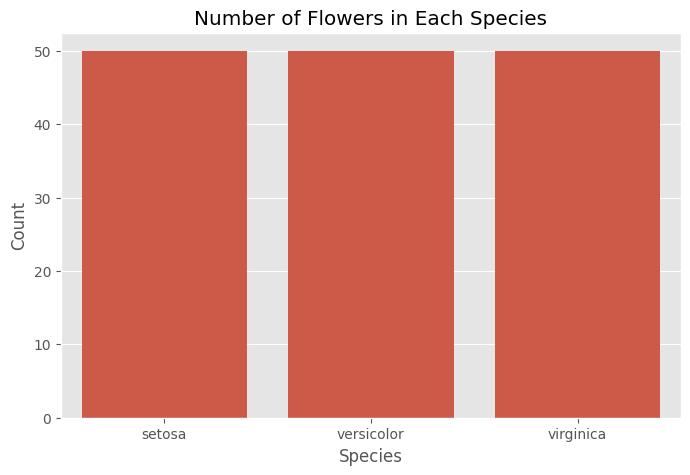

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=iris,
    x="species"
)

plt.title("Number of Flowers in Each Species")

plt.xlabel("Species")

plt.ylabel("Count")

plt.savefig(
    "images/species_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
species_percentage = (
    iris["species"]
    .value_counts(normalize=True)
    * 100
)

species_percentage

species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64

### Observations

- The Iris dataset is perfectly balanced, with 50 observations for each species.
- Each species represents approximately one-third of the dataset.
- A balanced target variable is beneficial for classification tasks because it reduces the risk of model bias toward a particular class.

## 5. Univariate Analysis

Univariate analysis examines each numerical feature individually to understand its distribution, variability, and potential outliers.

Histograms illustrate how the values are distributed, while box plots summarize the spread of the data and help identify possible outliers.

In [16]:
features = iris.columns[:-1]

features

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

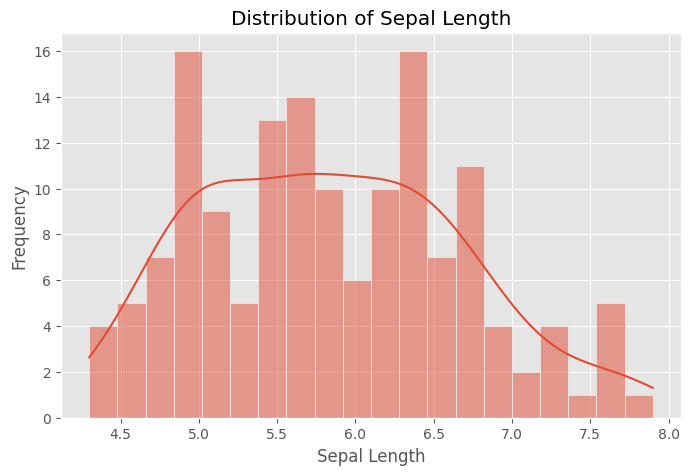

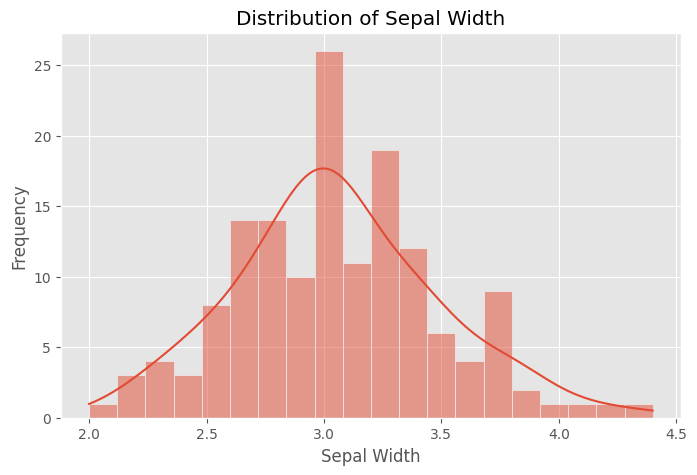

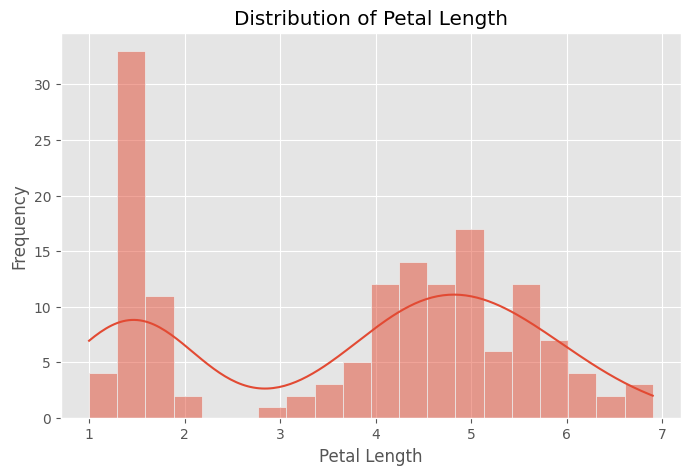

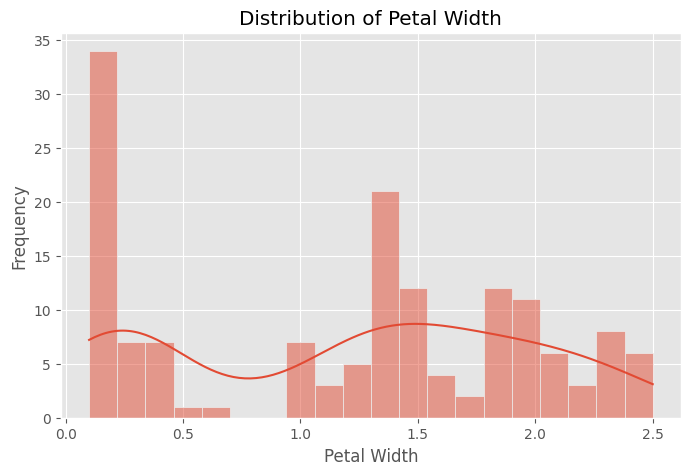

In [38]:
for feature in features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=iris,
        x=feature,
        kde=True,
        bins=20
    )

    plt.title(f"Distribution of {feature.replace('_', ' ').title()}")

    plt.xlabel(feature.replace("_", " ").title())

    plt.ylabel("Frequency")

    plt.savefig(
        f"images/{feature}_histogram.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

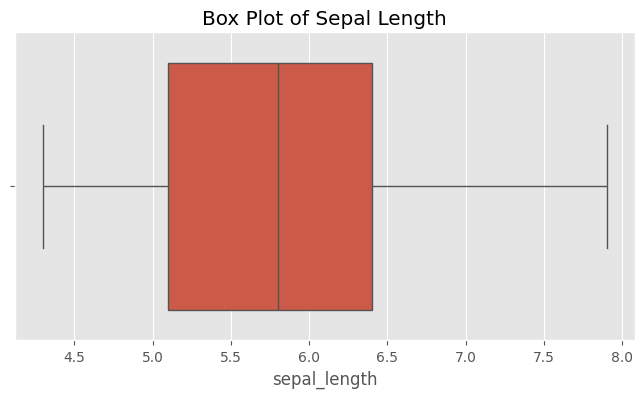

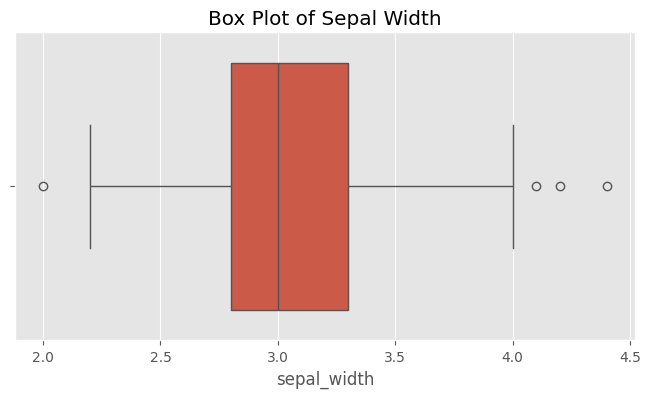

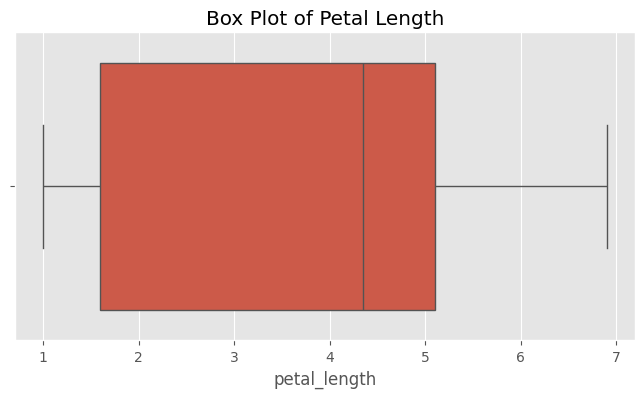

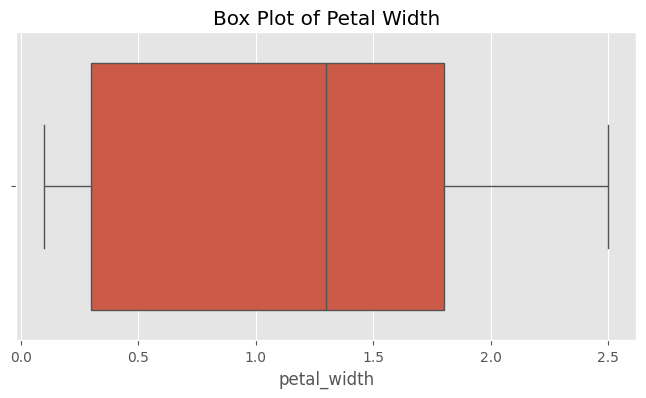

In [39]:
for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=iris,
        x=feature
    )

    plt.title(f"Box Plot of {feature.replace('_', ' ').title()}")

    plt.savefig(
        f"images/{feature}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

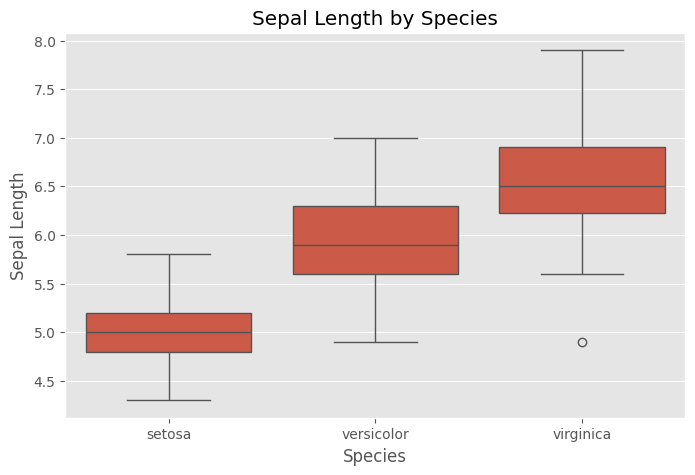

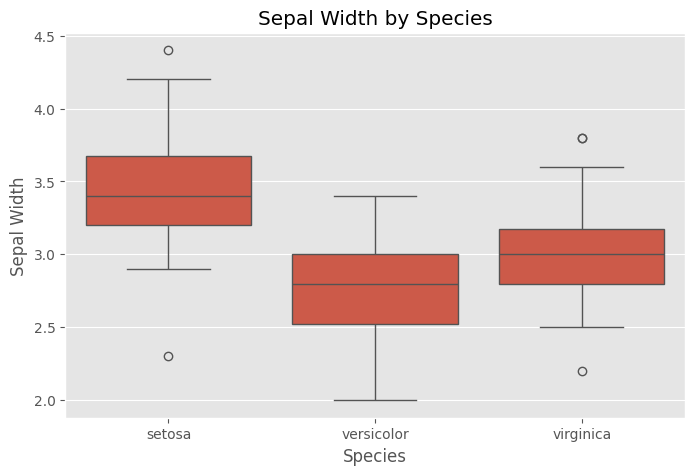

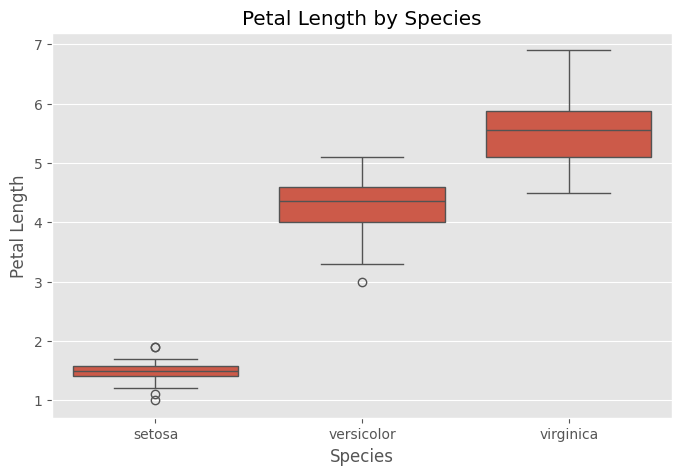

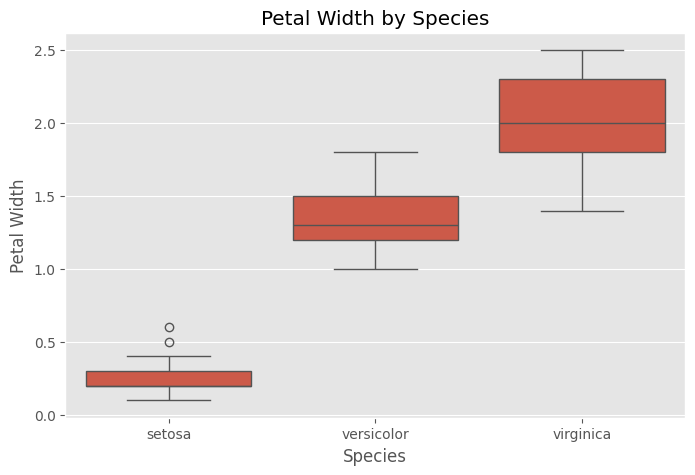

In [40]:
for feature in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=iris,
        x="species",
        y=feature
    )

    plt.title(f"{feature.replace('_', ' ').title()} by Species")

    plt.xlabel("Species")

    plt.ylabel(feature.replace("_", " ").title())

    plt.savefig(
        f"images/{feature}_species_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [20]:
iris.groupby("species")[features].describe().round(2)

sepal_length                                       sepal_width                                        petal_length                                        petal_width                                     
                  count  mean   std  min   25%  50%  75%  max       count  mean   std  min   25%  50%   75%  max        count  mean   std  min  25%   50%   75%  max       count  mean   std  min  25%  50%  75%  max
species                                                                                                                                                                                                              
setosa             50.0  5.01  0.35  4.3  4.80  5.0  5.2  5.8        50.0  3.43  0.38  2.3  3.20  3.4  3.68  4.4         50.0  1.46  0.17  1.0  1.4  1.50  1.58  1.9        50.0  0.25  0.11  0.1  0.2  0.2  0.3  0.6
versicolor         50.0  5.94  0.52  4.9  5.60  5.9  6.3  7.0        50.0  2.77  0.31  2.0  2.52  2.8  3.00  3.4         50.0  4.26  0.47  3.0  4.0  4.35  4.60  5.1        50.0  1.33  0.20  1.0  1.2  1.3  1.5  1.8
virginica          50.0  6.59  0.64  4.9  6.22  6.5  6.9  7.9        50.0  2.97  0.32  2.2  2.80  3.0  3.18  3.8         50.0  5.55  0.55  4.5  5.1  5.55  5.88  6.9        50.0  2.03  0.27  1.4  1.8  2.0  2.3  2.5

### Observations

- **Sepal Length:** Values overlap across species, although *Virginica* generally has the longest sepals.
- **Sepal Width:** This feature exhibits considerable overlap, making it less useful for distinguishing species on its own.
- **Petal Length:** *Setosa* is clearly separated from the other two species, while *Versicolor* and *Virginica* show only limited overlap.
- **Petal Width:** Similar to petal length, this feature provides strong separation between species.

Overall, petal measurements appear to be more informative than sepal measurements for distinguishing iris species.

## 6. Bivariate Analysis

Bivariate analysis explores the relationship between two variables simultaneously.

Scatter plots reveal how numerical features interact with each other, while color-coding observations by species helps determine whether different iris species can be visually distinguished based on their measurements.

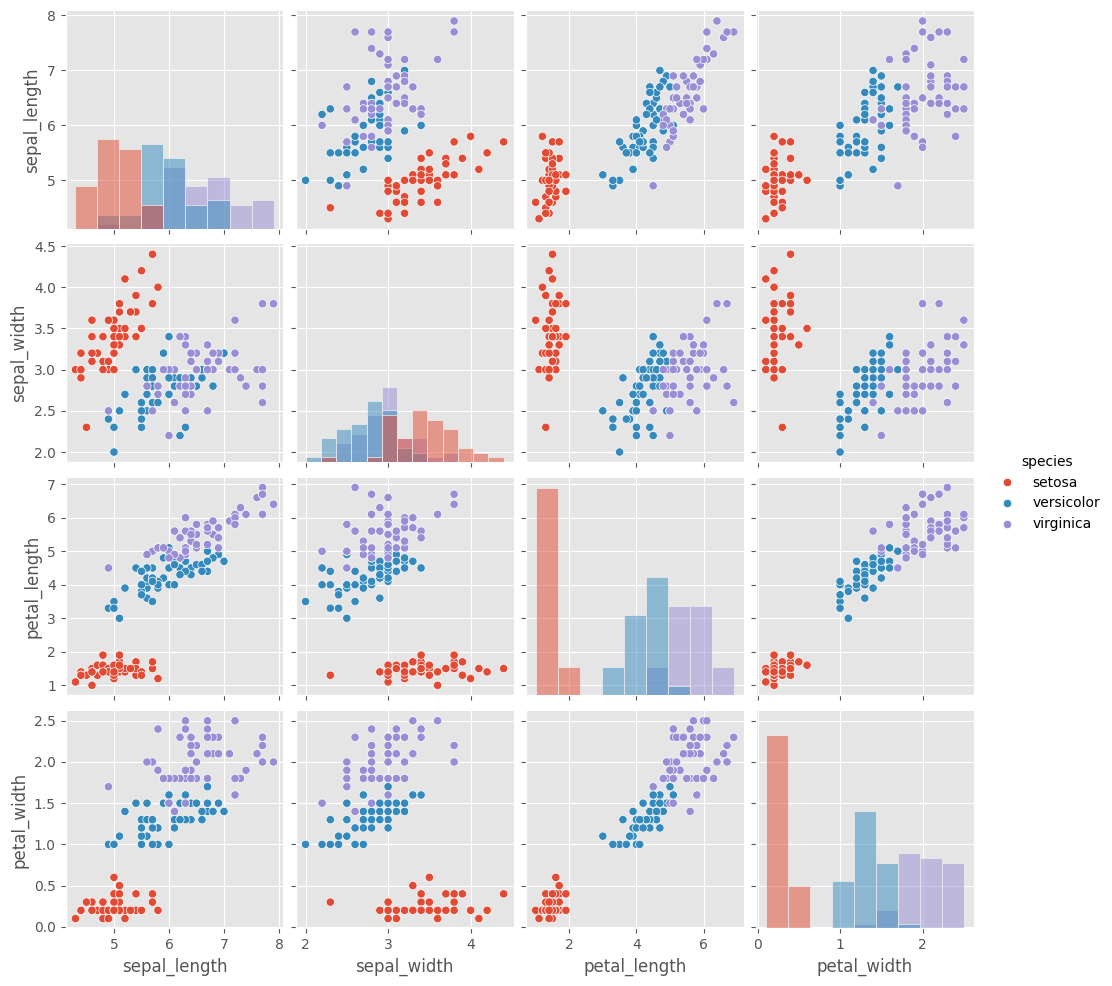

In [41]:
pair_plot = sns.pairplot(
    iris,
    hue="species",
    diag_kind="hist"
)

pair_plot.savefig(
    "images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

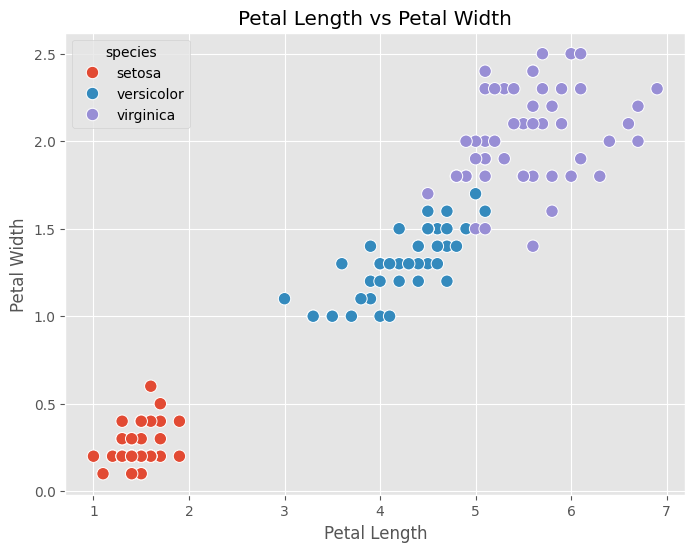

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=iris,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=80
)

plt.title("Petal Length vs Petal Width")

plt.xlabel("Petal Length")

plt.ylabel("Petal Width")

plt.savefig(
    "images/petal_length_vs_petal_width.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

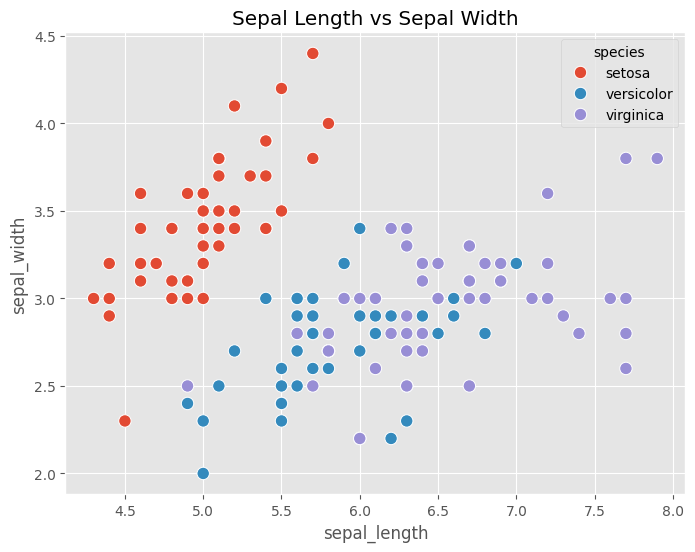

In [43]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=iris,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    s=80
)

plt.title("Sepal Length vs Sepal Width")

plt.savefig(
    "images/sepal_length_vs_sepal_width.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

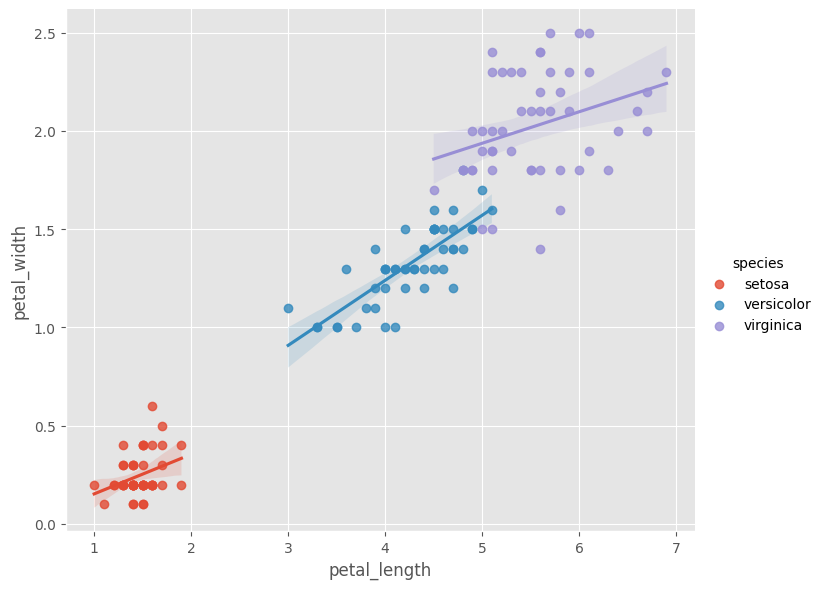

In [44]:
lm = sns.lmplot(
    data=iris,
    x="petal_length",
    y="petal_width",
    hue="species",
    height=6,
    aspect=1.2
)

lm.savefig(
    "images/regression_plot.png",
    dpi=300,
    bbox_inches="tight"
)

In [25]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### Observations

- Petal length and petal width exhibit a strong positive relationship.
- Setosa forms a distinct cluster that is clearly separated from the other two species.
- Versicolor and Virginica overlap in several feature combinations, although petal measurements still provide good separation.
- Scatter plots based on sepal measurements show considerably more overlap than those based on petal measurements.
- Petal measurements appear to be the most informative features for distinguishing iris species.

## 7. Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables.

The correlation coefficient ranges from **-1** to **+1**.

- Values close to **+1** indicate a strong positive relationship.
- Values close to **0** indicate little or no linear relationship.
- Values close to **-1** indicate a strong negative relationship.

A heatmap provides an intuitive visual representation of these relationships.

In [26]:
correlation_matrix = iris.corr(numeric_only=True)

correlation_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


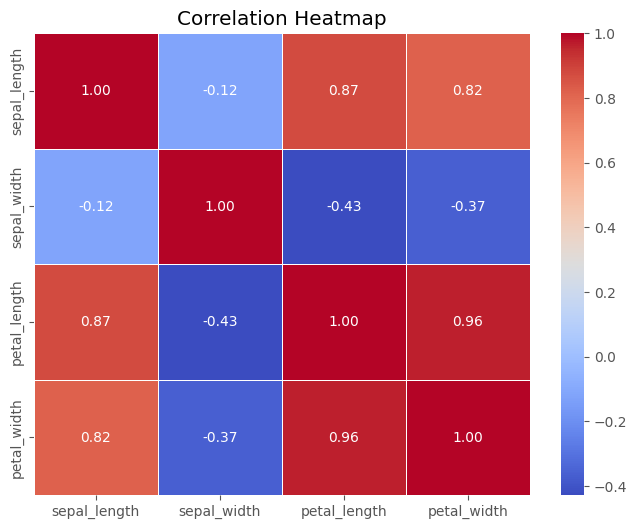

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")


plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
correlation_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False)
)

correlation_pairs

sepal_length  sepal_length    1.000000
sepal_width   sepal_width     1.000000
petal_width   petal_width     1.000000
petal_length  petal_length    1.000000
              petal_width     0.962865
petal_width   petal_length    0.962865
sepal_length  petal_length    0.871754
petal_length  sepal_length    0.871754
sepal_length  petal_width     0.817941
petal_width   sepal_length    0.817941
sepal_width   sepal_length   -0.117570
sepal_length  sepal_width    -0.117570
petal_width   sepal_width    -0.366126
sepal_width   petal_width    -0.366126
              petal_length   -0.428440
petal_length  sepal_width    -0.428440
dtype: float64

In [29]:
print("Correlation between Petal Length and Petal Width:")

print(
    iris["petal_length"].corr(
        iris["petal_width"]
    )
)

Correlation between Petal Length and Petal Width:
0.9628654314027963


In [30]:
print("Correlation between Sepal Length and Sepal Width:")

print(
    iris["sepal_length"].corr(
        iris["sepal_width"]
    )
)

Correlation between Sepal Length and Sepal Width:
-0.11756978413300198


### Observations

- Petal length and petal width exhibit a very strong positive correlation, indicating that flowers with longer petals generally have wider petals.
- Sepal length also shows a positive correlation with petal measurements, although the relationship is weaker.
- Sepal width has relatively weak or slightly negative correlations with the other numerical features.
- The heatmap confirms that petal measurements are the most closely related variables in the dataset.

## 8. Species Comparison

Grouping observations by species allows us to compare the average measurements of each iris species.

This analysis highlights the characteristics that distinguish Setosa, Versicolor, and Virginica.

In [31]:
species_mean = iris.groupby("species").mean(numeric_only=True)

species_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [32]:
iris.groupby("species").describe().round(2)

sepal_length                                       sepal_width                                        petal_length                                        petal_width                                     
                  count  mean   std  min   25%  50%  75%  max       count  mean   std  min   25%  50%   75%  max        count  mean   std  min  25%   50%   75%  max       count  mean   std  min  25%  50%  75%  max
species                                                                                                                                                                                                              
setosa             50.0  5.01  0.35  4.3  4.80  5.0  5.2  5.8        50.0  3.43  0.38  2.3  3.20  3.4  3.68  4.4         50.0  1.46  0.17  1.0  1.4  1.50  1.58  1.9        50.0  0.25  0.11  0.1  0.2  0.2  0.3  0.6
versicolor         50.0  5.94  0.52  4.9  5.60  5.9  6.3  7.0        50.0  2.77  0.31  2.0  2.52  2.8  3.00  3.4         50.0  4.26  0.47  3.0  4.0  4.35  4.60  5.1        50.0  1.33  0.20  1.0  1.2  1.3  1.5  1.8
virginica          50.0  6.59  0.64  4.9  6.22  6.5  6.9  7.9        50.0  2.97  0.32  2.2  2.80  3.0  3.18  3.8         50.0  5.55  0.55  4.5  5.1  5.55  5.88  6.9        50.0  2.03  0.27  1.4  1.8  2.0  2.3  2.5

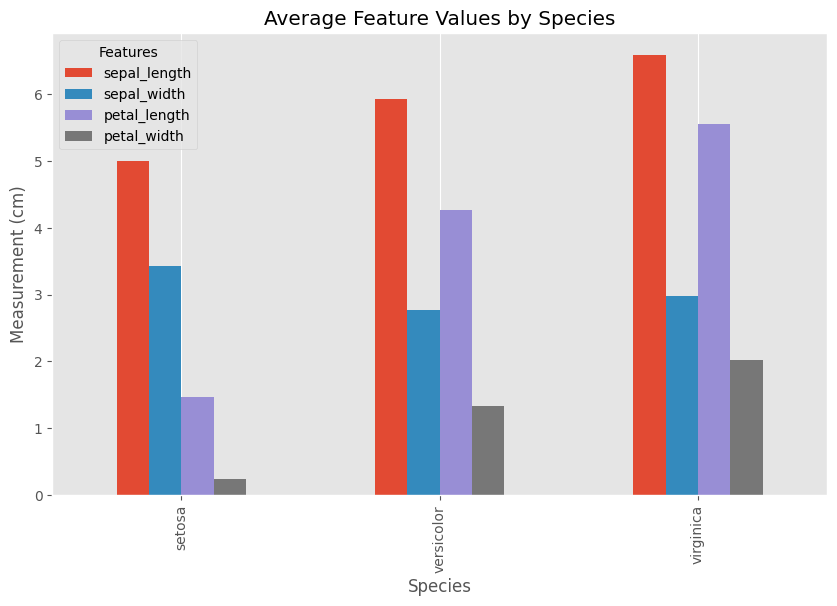

In [45]:
species_mean.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Feature Values by Species")

plt.xlabel("Species")
plt.ylabel("Measurement (cm)")

plt.legend(title="Features")

plt.grid(axis="y")

plt.savefig(
    "images/species_mean_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- Virginica has the largest average petal length and petal width.
- Setosa has the smallest petals among the three species.
- Sepal measurements vary between species but show greater overlap than petal measurements.
- Petal dimensions provide the clearest distinction between the three iris species.

## 9. Key Insights

The exploratory data analysis of the Iris dataset revealed several important patterns:

1. The dataset contains **150 observations** with **four numerical features** and **one categorical target variable**.

2. There are **no missing values or duplicate records**, making the dataset clean and suitable for analysis.

3. The dataset is **perfectly balanced**, with **50 samples** belonging to each of the three iris species.

4. **Petal length** and **petal width** are the most informative features for distinguishing between species.

5. **Setosa** forms a clearly distinct cluster and is almost linearly separable from the other two species.

6. **Versicolor** and **Virginica** exhibit some overlap, particularly when considering sepal measurements.

7. The strongest positive correlation exists between **petal length** and **petal width**, indicating that flowers with longer petals generally also have wider petals.

8. Sepal measurements are less effective for distinguishing species due to their greater overlap.

Overall, petal measurements provide the clearest separation among the three iris species and would likely be the most useful features for a classification model.

## 10. Conclusion

This project explored the Iris dataset using exploratory data analysis (EDA) techniques in Python.

The analysis began with data inspection and descriptive statistics, followed by visualizations that examined the distribution of individual features and the relationships between them. Correlation analysis and species comparisons further highlighted the distinguishing characteristics of each iris species.

The results indicate that petal length and petal width are the most significant features for differentiating the three species, while sepal measurements provide comparatively less separation. In particular, Setosa can be distinguished almost perfectly using petal measurements, whereas Versicolor and Virginica show partial overlap.

Overall, this project demonstrates how exploratory data analysis can reveal meaningful patterns within a dataset before applying machine learning techniques. The insights gained through EDA provide a strong foundation for future classification tasks using the Iris dataset.